In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# 1. Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/baren-kumar/ML-Material-Science-/refs/heads/main/carbon_fiber_epoxy_composite_dataset.csv')

In [3]:
df.head()

,carbon_fiber_fraction,epoxy_resin_fraction,volume_fraction,strength_MPa,stiffness_GPa,toughness_MJ_per_m3
0,0.449816,0.550184,0.559449,1156.999990,107.023571,11.055131
1,0.680286,0.319714,0.510829,1378.448318,131.305094,9.663145
2,0.592798,0.407202,0.442858,1311.334685,122.390584,9.196823
3,0.539463,0.460537,0.594139,1284.501346,123.284659,11.995826
4,0.362407,0.637593,0.555419,1062.766531,91.775722,13.108135


In [5]:
df.isnull().sum()

,0
carbon_fiber_fraction,0
epoxy_resin_fraction,0
volume_fraction,0
strength_MPa,0
stiffness_GPa,0
toughness_MJ_per_m3,0


In [6]:
# 2. Define Features and Target
X = df[['carbon_fiber_fraction', 'epoxy_resin_fraction', 'volume_fraction']]
y = df['strength_MPa']

In [7]:
# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# 4. Initialize and Train XGBoost
# Boosting helps minimize error iteratively
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [9]:
# 5. Predict and Evaluate
y_pred = xgb_model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} MPa")
print(f"MAE:      {mean_absolute_error(y_test, y_pred):.2f} MPa")

R2 Score: 0.9366
RMSE:     36.42 MPa
MAE:      29.13 MPa


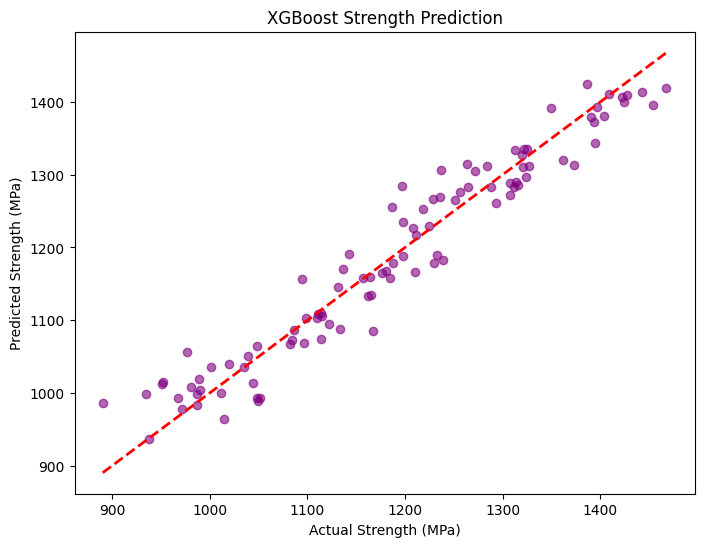

In [10]:
# 6. Plotting
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("XGBoost Strength Prediction")
plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.show()

In [11]:
new_carbon_fiber_fraction = 0.5
new_epoxy_resin_fraction = 0.5
new_volume_fraction = 0.5

# Create a DataFrame for the new input
new_data = pd.DataFrame({
    'carbon_fiber_fraction': [new_carbon_fiber_fraction],
    'epoxy_resin_fraction': [new_epoxy_resin_fraction],
    'volume_fraction': [new_volume_fraction]
})

# Predict the strength for the new data
predicted_strength = xgb_model.predict(new_data)

print(f"Predicted Strength (MPa) for the given input: {predicted_strength[0]:.2f}")

Predicted Strength (MPa) for the given input: 1202.95
